In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data_pad = "ER_DataExport-2025-12-31-171926.xlsx"
df = pd.read_excel(data_pad, sheet_name="Emissies")
vuurwerk_PM2 = df.loc[(df["Sector"] == "Consumenten") &
    (df["Stof"] == "Fijnstof (PM2,5)") &
    (df["Emissieoorzaak"] == "Afsteken vuurwerk")][["Emissieoorzaak", "Emissie", "Eenheid"]]
vuurwerk_PM2

vuurwerk_PM10 = df.loc[(df["Sector"] == "Consumenten") &
    (df["Stof"] == "Fijnstof (PM10)") &
    (df["Emissieoorzaak"] == "Afsteken vuurwerk")][["Emissieoorzaak", "Emissie", "Eenheid"]]
vuurwerk_PM10

vuurwerk = vuurwerk_PM2.groupby(["Emissieoorzaak","Eenheid"])["Emissie"].sum().reset_index()
vuurwerk = vuurwerk[["Emissieoorzaak", "Emissie", "Eenheid"]]
vuurwerk

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Emissieoorzaak,Emissie,Eenheid
0,Afsteken vuurwerk,711578.0,kg


In [3]:

personen_auto = (df.loc[(df["Emissieoorzaak"].str.contains("Uitlaatgassen Personenauto's", case=False)) &
    (df["Stof"] == "Fijnstof (PM2,5)")][["Emissieoorzaak", "Emissie", "Eenheid"]].reset_index(drop=True))
personen_auto = pd.DataFrame({
    "Emissieoorzaak": ["Personenauto's"],
    "Emissie": personen_auto["Emissie"].sum(),
    "Eenheid": personen_auto["Eenheid"].iloc[0]})
personen_auto

,Emissieoorzaak,Emissie,Eenheid
0,Personenauto's,242884.186526,kg


In [4]:

bedrijfsvoertuigen = (df.loc[(df["Emissieoorzaak"].str.contains("Uitlaatgassen lichte bedrijfsvoertuigen", case=False)) &
    (df["Stof"] == "Fijnstof (PM2,5)")][["Emissieoorzaak", "Emissie", "Eenheid"]].reset_index(drop=True))

bedrijfsvoertuigen = pd.DataFrame({
    "Emissieoorzaak": ["Lichte bedrijfsvoertuigen"],
    "Emissie": bedrijfsvoertuigen["Emissie"].sum(),
    "Eenheid": bedrijfsvoertuigen["Eenheid"].iloc[0]})
bedrijfsvoertuigen

,Emissieoorzaak,Emissie,Eenheid
0,Lichte bedrijfsvoertuigen,176492.49375,kg


In [5]:
zware_voertuigen = (df.loc[(df["Emissieoorzaak"].str.contains("uitlaatgassen zware bedrijfsvoertuigen", case=False))&
                    (df["Stof"] == "Fijnstof (PM2,5)")][["Stof", "Emissieoorzaak", "Emissie", "Eenheid"]])

zware_voertuigen = pd.DataFrame({
    "Emissieoorzaak": ["Zware bedrijfsvoeruigen"],
    "Emissie": zware_voertuigen["Emissie"].sum(),
    "Eenheid": ["kg"]})
zware_voertuigen

,Emissieoorzaak,Emissie,Eenheid
0,Zware bedrijfsvoeruigen,132463.800683,kg


In [6]:
motorfietsen = (df.loc[(df["Emissieoorzaak"].str.contains("uitlaatgassen motorfietsen", case=False)) &
    (df["Stof"] == "Fijnstof (PM2,5)")][["Stof", "Emissieoorzaak", "Emissie", "Eenheid"]])

motorfietsen = pd.DataFrame({
    "Emissieoorzaak": ["Motorfietsen"],
    "Emissie": motorfietsen["Emissie"].sum(),
    "Eenheid": ["kg"]})
motorfietsen

,Emissieoorzaak,Emissie,Eenheid
0,Motorfietsen,23595.69193,kg


In [7]:
brommers = (df.loc[(df["Emissieoorzaak"].str.contains("uitlaatgassen bromfietsen", case=False)) &
    (df["Stof"] == "Fijnstof (PM2,5)")][["Stof", "Emissieoorzaak", "Emissie", "Eenheid"]])

brommers = pd.DataFrame({
    "Emissieoorzaak": ["Bromfietsen"],
    "Emissie": brommers["Emissie"].sum(),
    "Eenheid": ["kg"]})
brommers

,Emissieoorzaak,Emissie,Eenheid
0,Bromfietsen,14117.67125,kg


In [7]:
totaal_fijnstof = pd.concat([personen_auto, bedrijfsvoertuigen, zware_voertuigen, motorfietsen, brommers, vuurwerk])
totaal_fijnstof["Emissie (t)"] = totaal_fijnstof["Emissie"]/1000
totaal_fijnstof = totaal_fijnstof.sort_values(by="Emissie (t)", ascending=True)

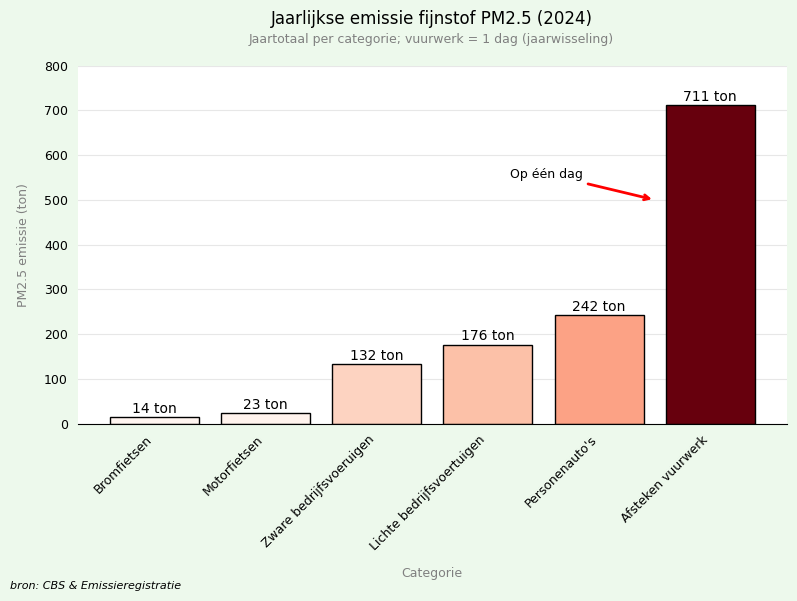

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
norm = ((totaal_fijnstof["Emissie (t)"] - totaal_fijnstof["Emissie (t)"].min()) / 
        (totaal_fijnstof["Emissie (t)"].max() - totaal_fijnstof["Emissie (t)"].min()))
cmap = plt.cm.Reds
kleuren = cmap(norm)
ax.bar(totaal_fijnstof["Emissieoorzaak"], totaal_fijnstof["Emissie (t)"],
       color=kleuren, edgecolor="black", label=totaal_fijnstof["Emissieoorzaak"], zorder=2)
ax.set_title("Jaarlijkse emissie fijnstof PM2.5 (2024)", pad=30)
ax.text(0.85, 850, "Jaartotaal per categorie; vuurwerk = 1 dag (jaarwisseling)", color="grey", fontsize=9)

ax.set_xlabel("Categorie", labelpad=10, color="grey", fontsize=9)
ax.set_ylabel("PM2.5 emissie (ton)", labelpad=10, color="grey", fontsize=9)
ax.tick_params(axis="x", rotation=45, width=0)
ax.tick_params(axis="y", width=0)
plt.xticks(ha="right", fontsize=9)
plt.yticks(np.arange(0, 900, 100), fontsize=9)
ax.grid(axis="y", alpha=0.3, zorder=1)

for i, label in enumerate(totaal_fijnstof["Emissie (t)"].astype(int)):
    ax.text(i, label+10, f"{label} ton", ha="center")

ax.annotate("Op één dag",
            xy=(4.5, 500),
            xytext=(3.2, 550),
            fontsize=9,
            arrowprops=dict(arrowstyle="->", lw=2, color="red"))

ax.spines[["left","top","right"]].set_visible(False)
fig.set_facecolor("#EDF9EC")
fig.text(0.01, 0.01, "bron: CBS & Emissieregistratie", fontsize=8, fontstyle="italic")
#ax.legend()
plt.tight_layout()
#plt.savefig("vuurwerk_vervoer.png")
plt.show()

In [9]:
varkens = (df.loc[(df["Emissieoorzaak"].str.contains("Veestapel, vleesvarkens", case=False)) & (df["Stof"] == "Fijnstof (PM2,5)")]
    [["Stof", "Emissieoorzaak", "Emissie", "Eenheid"]])

varkens = pd.DataFrame({
    "Emissieoorzaak": ["Vleesvarkens"],
    "Emissie": varkens["Emissie"].sum(),
    "Eenheid": ["kg"]})
varkens

,Emissieoorzaak,Emissie,Eenheid
0,Vleesvarkens,21549.714325,kg


In [10]:
kippen = (df.loc[(df["Emissieoorzaak"].str.contains("Veestapel, vleeskuikens", case=False)) & (df["Stof"] == "Fijnstof (PM2,5)")]
    [["Stof", "Emissieoorzaak", "Emissie", "Eenheid"]])

kippen = pd.DataFrame({
    "Emissieoorzaak": ["Vleeskuikens"],
    "Emissie": kippen["Emissie"].sum(),
    "Eenheid": ["kg"]})
kippen

,Emissieoorzaak,Emissie,Eenheid
0,Vleeskuikens,61528.141486,kg


In [11]:
koeien = (df.loc[(df["Emissieoorzaak"].str.contains("Veestapel, melkkoeien", case=False)) & (df["Stof"] == "Fijnstof (PM2,5)")]
    [["Stof", "Emissieoorzaak", "Emissie", "Eenheid"]])

koeien = pd.DataFrame({
    "Emissieoorzaak": ["Melkkoeien"],
    "Emissie": koeien["Emissie"].sum(),
    "Eenheid": ["kg"]})
koeien

,Emissieoorzaak,Emissie,Eenheid
0,Melkkoeien,53031.476772,kg


In [12]:
kalveren = (df.loc[(df["Emissieoorzaak"].str.contains("Veestapel, vleeskalveren", case=False)) & (df["Stof"] == "Fijnstof (PM2,5)")]
    [["Stof", "Emissieoorzaak", "Emissie", "Eenheid"]])

kalveren = pd.DataFrame({
    "Emissieoorzaak": ["Vleeskalveren"],
    "Emissie": kalveren["Emissie"].sum(),
    "Eenheid": ["kg"]})
kalveren

,Emissieoorzaak,Emissie,Eenheid
0,Vleeskalveren,8347.838636,kg


In [13]:
hennen = (df.loc[(df["Emissieoorzaak"].str.contains("Veestapel, leghennen", case=False)) & (df["Stof"] == "Fijnstof (PM2,5)")]
    [["Stof", "Emissieoorzaak", "Emissie", "Eenheid"]])

hennen = pd.DataFrame({
    "Emissieoorzaak": ["Leghennen"],
    "Emissie": hennen["Emissie"].sum(),
    "Eenheid": ["kg"]})
hennen

,Emissieoorzaak,Emissie,Eenheid
0,Leghennen,125299.329355,kg


In [14]:
fijnstof_vuurwerk = pd.concat([vuurwerk, varkens, kippen, koeien, kalveren, hennen]).sort_values(by="Emissie").reset_index(drop=True)
fijnstof_vuurwerk["Emissie (t)"] = fijnstof_vuurwerk["Emissie"]/1000
fijnstof_vuurwerk

,Emissieoorzaak,Emissie,Eenheid,Emissie (t)
0,Vleeskalveren,8347.838636,kg,8.347839
1,Vleesvarkens,21549.714325,kg,21.549714
2,Melkkoeien,53031.476772,kg,53.031477
3,Vleeskuikens,61528.141486,kg,61.528141
4,Leghennen,125299.329355,kg,125.299329
5,Afsteken vuurwerk,711578.000000,kg,711.578000


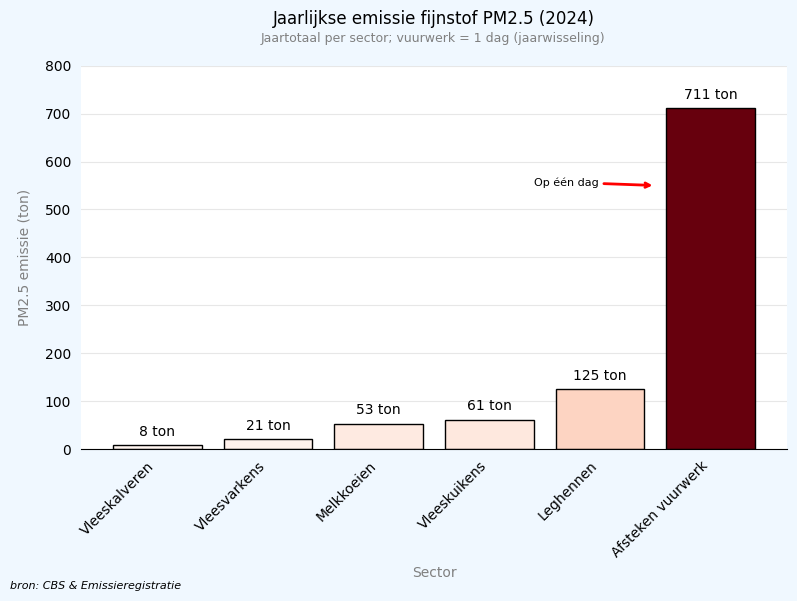

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

norm = ((fijnstof_vuurwerk["Emissie (t)"] - fijnstof_vuurwerk["Emissie (t)"].min())
        / (fijnstof_vuurwerk["Emissie (t)"].max() - fijnstof_vuurwerk["Emissie (t)"].min()))
cmap = plt.cm.Reds
kleuren = cmap(norm)

ax.bar(fijnstof_vuurwerk["Emissieoorzaak"], fijnstof_vuurwerk["Emissie (t)"],
       color=kleuren, edgecolor="black", label=fijnstof_vuurwerk["Emissieoorzaak"], zorder=2)

ax.set_title("Jaarlijkse emissie fijnstof PM2.5 (2024)", pad=30)
ax.text(0.93, 850, "Jaartotaal per sector; vuurwerk = 1 dag (jaarwisseling)",
        color="grey", fontsize=9)
ax.set_xlabel("Sector", color="grey")
ax.set_ylabel("PM2.5 emissie (ton)", color="grey", labelpad=10)
ax.tick_params(axis="x", labelrotation=45,width=0)
plt.xticks(ha="right")
ax.tick_params(axis="y", width=0)

ax.grid(axis="y", alpha=0.3, zorder=1)
ax.set_yticks(np.arange(0, 900, 100))

# labels in grafiek
for i, label in enumerate(fijnstof_vuurwerk["Emissie (t)"].astype(int)):
    ax.text(i, label+20, f"{label} ton", ha="center")

# tekst met pijlpunt
ax.annotate("Op één dag", 
            xy=(4.5, 550),  # pijlpunt
            xytext=(3.4, 550),  # tekst positie
            fontsize=8,
            arrowprops=dict(arrowstyle='->', lw=2, color="red"))

ax.spines[["top","right", "left"]].set_visible(False)

fig.set_facecolor("#F0F8FF")
fig.text(0.01, 0.01, "bron: CBS & Emissieregistratie", fontsize=8, fontstyle="italic")

plt.tight_layout()
#plt.savefig("vuurwerk_dieren.png")
plt.show()

In [16]:
houtstook = (df.loc[(df["Emissieoorzaak"].str.contains("Vuurhaarden", case=False)) & (df["Stof"] == "Fijnstof (PM2,5)")]
                      [["Stof", "Emissieoorzaak", "Emissie", "Eenheid"]])

In [17]:
houtstook = pd.DataFrame({
    "Emissieoorzaak": ["Houtstook"],
    "Emissie": houtstook["Emissie"].sum(),
    "Eenheid": ["kg"]})
houtstook

,Emissieoorzaak,Emissie,Eenheid
0,Houtstook,3.590777e+06,kg


In [18]:
vuurwerk_vs_houtstook = pd.concat([vuurwerk, houtstook])
vuurwerk_vs_houtstook["Emissie (t)"] = vuurwerk_vs_houtstook["Emissie"]/1000
vuurwerk_vs_houtstook = vuurwerk_vs_houtstook.sort_values(by="Emissie (t)", ascending=False)

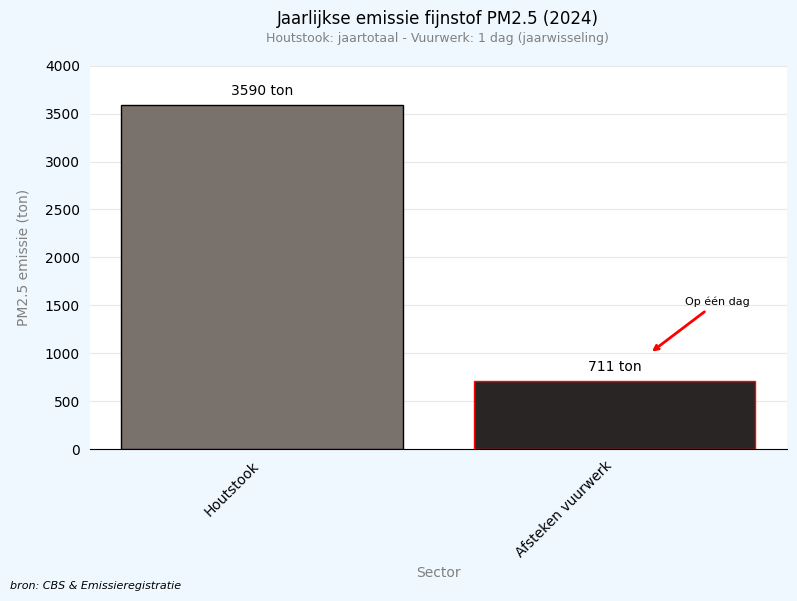

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))

kleuren = ["#79716B", "#292524"]

ax.bar(vuurwerk_vs_houtstook["Emissieoorzaak"], vuurwerk_vs_houtstook["Emissie (t)"],
       color=kleuren,edgecolor=["black","red"], label=vuurwerk_vs_houtstook["Emissieoorzaak"], zorder=3)

ax.set_title("Jaarlijkse emissie fijnstof PM2.5 (2024)", pad=30)
ax.text(0.01, 4250, "Houtstook: jaartotaal - Vuurwerk: 1 dag (jaarwisseling)",
        color="grey", fontsize=9)
ax.set_xlabel("Sector", color="grey")
ax.set_ylabel("PM2.5 emissie (ton)", color="grey", labelpad=10)
ax.tick_params(axis="x", labelrotation=45,width=0)
plt.xticks(ha="right")
ax.tick_params(axis="y", width=0)

ax.grid(axis="y", alpha=0.3, zorder=1)
ax.set_yticks(np.arange(0, 4500, 500))

# labels in grafiek
for i, label in enumerate(vuurwerk_vs_houtstook["Emissie (t)"].astype(int)):
    ax.text(i, label+100, f"{label} ton", ha="center")

# tekst met pijlpunt
ax.annotate("Op één dag", 
            xy=(1.1, 1000),  # pijlpunt
            xytext=(1.2, 1500),  # tekst positie
            fontsize=8,
            arrowprops=dict(arrowstyle='->', lw=2, color="red"))

ax.spines[["top","right", "left"]].set_visible(False)

fig.set_facecolor("#F0F8FF")
fig.text(0.01, 0.01, "bron: CBS & Emissieregistratie", fontsize=8, fontstyle="italic")

plt.tight_layout()
#plt.savefig("vuurwerk_houtstook.png")
plt.show()